# 04f: Đánh Giá & Trực Quan Hóa Mô Hình MetaBlock Fusion (HAM10000)

Notebook này dùng để tải lại weights mô hình tốt nhất từ file `.pth` đã được huấn luyện trước đó, tiến hành dự đoán trên tập kiểm định gốc (Validation set) để xuất báo cáo đánh giá chi tiết và vẽ các đồ thị trực quan hóa kết quả.

---

In [1]:
# 1. Thiết lập Môi trường & Mount Google Drive
import os
import sys
import glob
import cv2
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Kiểm tra môi trường Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🔥 Đang chạy trên Google Colab. Bắt đầu cài đặt các thư viện cần thiết...")
    !pip install -q timm kagglehub albumentations scikit-learn matplotlib seaborn opencv-python-headless

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Đường dẫn checkpoint trên Google Drive
    BEST_MODEL_PATH = '/content/drive/MyDrive/PBL7/saved_models/ham10000_effnet_oversampled_best.pth'
else:
    print("💻 Đang chạy trên môi trường local.")
    BEST_MODEL_PATH = './ham10000_effnet_oversampled_best.pth'

print(f"📌 Đường dẫn mặc định của checkpoint: {BEST_MODEL_PATH}")

💻 Đang chạy trên môi trường local.
📌 Đường dẫn mặc định của checkpoint: ./ham10000_effnet_oversampled_best.pth


In [2]:
# 2. Tải dữ liệu bằng kagglehub và quét tìm file ảnh
import kagglehub

print("📥 Bắt đầu tải tập dữ liệu HAM10000 từ Kaggle...")
try:
    dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print(f"✅ Dữ liệu được tải về thành công tại: {dataset_path}")
except Exception as e:
    print(f"❌ Lỗi khi tải dữ liệu từ Kaggle: {e}")
    dataset_path = "./ham10000"

# Quét tìm toàn bộ tệp JPG để ánh xạ image_id -> đường dẫn ảnh tuyệt đối
image_paths_dict = {}
for img_path in glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True):
    img_id = os.path.splitext(os.path.basename(img_path))[0]
    image_paths_dict[img_id] = img_path

print(f"📊 Tổng số ảnh quét được và lập bản đồ: {len(image_paths_dict)}")

📥 Bắt đầu tải tập dữ liệu HAM10000 từ Kaggle...
Resuming download from 381681664 bytes (5201232847 bytes left)...
Resuming download to /Users/hhh/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/2.archive (381681664/5582914511) bytes left.


100%|██████████| 5.20G/5.20G [15:28<00:00, 5.60MB/s] 

Extracting files...


✅ Dữ liệu được tải về thành công tại: /Users/hhh/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2
📊 Tổng số ảnh quét được và lập bản đồ: 10015


In [3]:
# 3. Khởi tạo Metadata
metadata_file = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith('metadata.csv'):
            metadata_file = os.path.join(root, f)
            break
    if metadata_file:
        break

if not metadata_file:
    raise FileNotFoundError("❌ Không tìm thấy tệp tin HAM10000_metadata.csv trong thư mục dữ liệu tải về!")

df = pd.read_csv(metadata_file)
print(f"✅ Đọc Metadata thành công. Kích thước: {df.shape[0]} dòng, {df.shape[1]} cột")

✅ Đọc Metadata thành công. Kích thước: 10015 dòng, 7 cột


In [4]:
# 4. Tiền xử lý dữ liệu và chia tập Validation (Đảm bảo đồng bộ ngẫu nhiên)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# A. Xử lý giá trị bị khuyết của cột tuổi
med_age = df['age'].median()
df['age'] = df['age'].fillna(med_age)

# B. Chuẩn hóa cột Age
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

# C. Mã hóa One-Hot
df_encoded = pd.get_dummies(df, columns=['sex', 'localization'], prefix=['sex', 'localization'])
tab_cols = ['age_scaled'] + [c for c in df_encoded.columns if c.startswith('sex_') or c.startswith('localization_')]

# D. Ánh xạ nhãn sang số nguyên (0-6)
label_map = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
df_encoded['target'] = df_encoded['dx'].map(label_map)

for col in tab_cols:
    df_encoded[col] = df_encoded[col].astype(np.float32)

# E. Chia tập Stratified Train/Val (80/20) với random_state=42 để giữ nguyên tập kiểm định
_, val_df = train_test_split(
    df_encoded,
    test_size=0.20,
    random_state=42,
    stratify=df_encoded['target']
)

print(f"🎯 Kích thước tập Validation giữ nguyên để đánh giá: {len(val_df)} mẫu")
dx_full_names = {
    'nv': 'Melanocytic Nevi (nv - Nốt ruồi lành tính)',
    'mel': 'Melanoma (mel - Ung thư hắc tố cực ác)',
    'bkl': 'Benign Keratosis (bkl - Dày sừng lành tính)',
    'bcc': 'Basal Cell Carcinoma (bcc - Ung thư biểu mô tế bào đáy)',
    'akiec': 'Actinic Keratosis (akiec - Ung thư biểu mô tế bào vảy tại chỗ)',
    'vasc': 'Vascular Lesions (vasc - Tổn thương mạch máu)',
    'df': 'Dermatofibroma (df - U xơ da lành tính)'
}

🎯 Kích thước tập Validation giữ nguyên để đánh giá: 2003 mẫu


In [5]:
# 5. Xây dựng Dataset & DataLoader cho tập Validation
import albumentations as A
from albumentations.pytorch import ToTensorV2

class HAM10000Dataset(Dataset):
    def __init__(self, df_meta, image_paths, tab_columns):
        self.df = df_meta.reset_index(drop=True)
        self.image_paths = image_paths
        self.tab_columns = tab_columns
        self.transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']

        if img_id in self.image_paths:
            img_path = self.image_paths[img_id]
            image = cv2.imread(img_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = np.zeros((224, 224, 3), dtype=np.uint8)

        augmented = self.transform(image=image)
        img_tensor = augmented['image']

        tab_vector = row[self.tab_columns].values.astype(np.float32)
        tab_tensor = torch.tensor(tab_vector, dtype=torch.float32)

        label = int(row['target'])
        return img_tensor, tab_tensor, torch.tensor(label, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Thiết bị phần cứng suy luận: {device}")

val_dataset = HAM10000Dataset(val_df, image_paths_dict, tab_cols)

num_workers = 4 if os.cpu_count() >= 4 else 2
if sys.platform == 'darwin':
    num_workers = 0

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if num_workers > 0 else False
)

print(f"✅ Dataloader Validation thành công. Số lượng batches: {len(val_loader)}")

💻 Thiết bị phần cứng suy luận: cpu
✅ Dataloader Validation thành công. Số lượng batches: 63


In [ ]:
# 5.1 Trực quan hóa 10 mẫu ảnh ngẫu nhiên từ tập Validation (2 hàng x 5 cột)
import random
import numpy as np
import matplotlib.pyplot as plt

# Chọn ngẫu nhiên 10 chỉ số từ tập validation
dataset_size = len(val_dataset)
random_indices = random.sample(range(dataset_size), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

dx_to_full_label = {
    'akiec': 'Actinic Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesion'
}

for i, idx in enumerate(random_indices):
    # Lấy thông tin dòng từ val_df
    row_info = val_dataset.df.iloc[idx]
    image_id = row_info['image_id']
    
    # Tra cứu dòng gốc trong df ban đầu để có đầy đủ thông tin giới tính và vị trí gốc (tránh cột bị one-hot encode)
    original_row = df[df['image_id'] == image_id].iloc[0]
    dx = original_row['dx']
    age = int(original_row['age']) if not pd.isna(original_row['age']) else 'N/A'
    sex = str(original_row['sex']).capitalize()
    loc = str(original_row['localization']).capitalize()
    
    # Lấy tensor hình ảnh từ dataset
    img_tensor, _, _ = val_dataset[idx]
    
    # Chuyển đổi tensor sang numpy và khôi phục màu chuẩn (de-normalize)
    img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    # Vẽ ảnh
    axes[i].imshow(img_np)
    axes[i].axis('off')
    
    # Thiết lập tiêu đề thông tin chi tiết của mẫu ảnh
    full_dx_name = dx_to_full_label.get(dx, dx.upper())
    title_text = f"Class: {dx.upper()} ({full_dx_name})\n{sex}, {age} tuổi\nVị trí: {loc}"
    axes[i].set_title(title_text, fontsize=10, weight='bold', pad=8, color='#2c3e50')

plt.suptitle('🖼️ Trực quan hóa 10 mẫu ảnh ngẫu nhiên trong tập Validation (2 hàng x 5 cột)', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [6]:
# 6. Thiết kế mô hình MetaBlock Fusion
import timm

class MetaBlockFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=7, hidden_dim=256):
        super().__init__()

        self.img_net = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)

        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, hidden_dim)
        )

        self.img_proj = nn.Sequential(
            nn.Linear(1536, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        self.meta_scale = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.meta_shift = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, tab, return_gate=False):
        f_img_raw = self.img_net(img)     # (B, 1536)
        f_img = self.img_proj(f_img_raw)  # (B, 256)

        f_tab = self.tab_proj(tab)        # (B, 256)

        scale = self.meta_scale(f_tab)    # (B, 256)
        shift = self.meta_shift(f_tab)    # (B, 256)

        fused = f_img * scale + shift
        out = self.classifier(fused)

        if return_gate:
            return out, scale
        return out

In [7]:
# 7. Khởi tạo mô hình & Tải weights tối ưu đã lưu
tab_dim = len(tab_cols)
model = MetaBlockFusionModel(tab_dim=tab_dim, num_classes=7).to(device)

weights_candidates = [
    'ham10000_effnet_oversampled_best.pth',
    './ham10000_effnet_oversampled_best.pth',
    '../ham10000_effnet_oversampled_best.pth',
    '/content/ham10000_effnet_oversampled_best.pth',
    '/content/drive/MyDrive/PBL7/saved_models/ham10000_effnet_oversampled_best.pth',
]
if BEST_MODEL_PATH not in weights_candidates:
    weights_candidates.insert(0, BEST_MODEL_PATH)

loaded = False
for path in weights_candidates:
    if os.path.exists(path):
        print(f"📂 Đang tải weights mô hình tối ưu nhất từ: {path}")
        model.load_state_dict(torch.load(path, map_location=device))
        loaded = True
        break

if loaded:
    print("✅ Đã tải weights thành công!")
else:
    print("❌ Không tìm thấy weights mô hình ở các đường dẫn dự phòng. Vui lòng tải file weights '.pth' lên thư mục làm việc hiện tại.")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

📂 Đang tải weights mô hình tối ưu nhất từ: ham10000_effnet_oversampled_best.pth
✅ Đã tải weights thành công!



================ 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT (BEST MODEL) ================
                                                                precision    recall  f1-score   support

Actinic Keratosis (akiec - Ung thư biểu mô tế bào vảy tại chỗ)     0.7286    0.7846    0.7556        65
       Basal Cell Carcinoma (bcc - Ung thư biểu mô tế bào đáy)     0.8288    0.8932    0.8598       103
                   Benign Keratosis (bkl - Dày sừng lành tính)     0.7885    0.8136    0.8009       220
                       Dermatofibroma (df - U xơ da lành tính)     1.0000    0.9130    0.9545        23
                        Melanoma (mel - Ung thư hắc tố cực ác)     0.7339    0.7175    0.7256       223
                    Melanocytic Nevi (nv - Nốt ruồi lành tính)     0.9495    0.9389    0.9441      1341
                 Vascular Lesions (vasc - Tổn thương mạch máu)     0.8667    0.9286    0.8966        28

                                                      accuracy                         0.

/var/folders/q5/7lqn73z14kdgf2zsrn7wn0540000gn/T/ipykernel_40086/2770720675.py:32: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


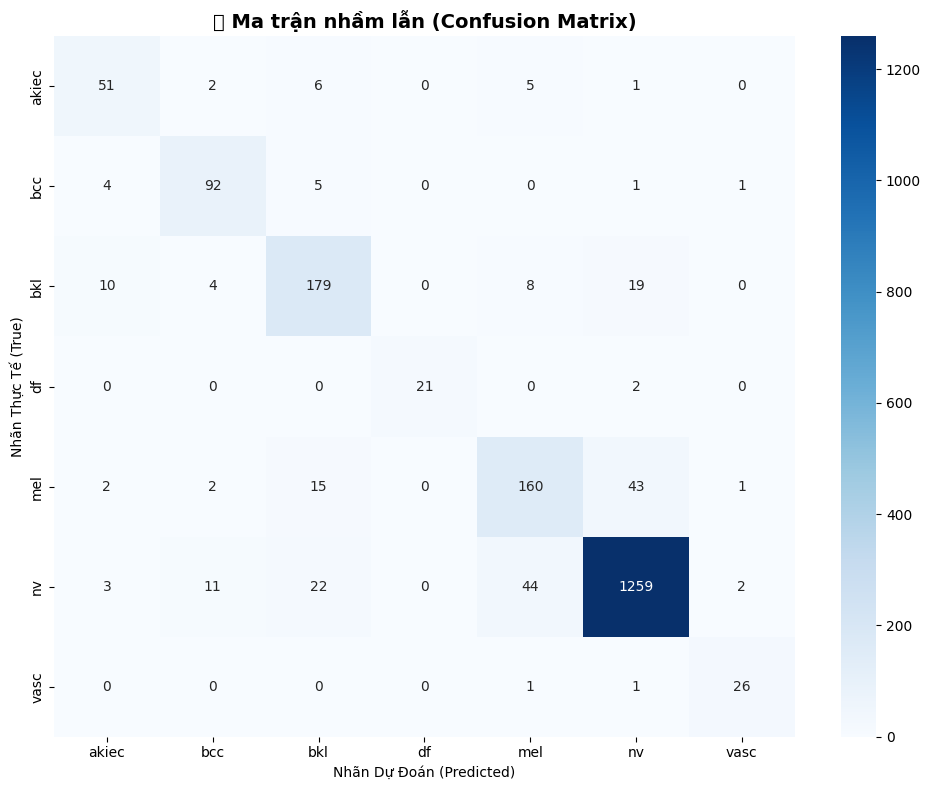

In [8]:
# 8. Chạy suy luận và xuất Báo cáo phân loại & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, tabs, labels in val_loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        outputs = model(imgs, tabs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

ordered_target_names = [dx_full_names[k] for k, v in sorted(label_map.items(), key=lambda item: item[1])]

print("\n================ 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT (BEST MODEL) ================")
print(classification_report(all_labels, all_preds, target_names=ordered_target_names, digits=4))

# Vẽ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
short_classes_labels = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=short_classes_labels, yticklabels=short_classes_labels)
plt.title('🎯 Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, weight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted)')
plt.ylabel('Nhãn Thực Tế (True)')
plt.tight_layout()
plt.show()

/var/folders/q5/7lqn73z14kdgf2zsrn7wn0540000gn/T/ipykernel_40086/3449164537.py:43: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


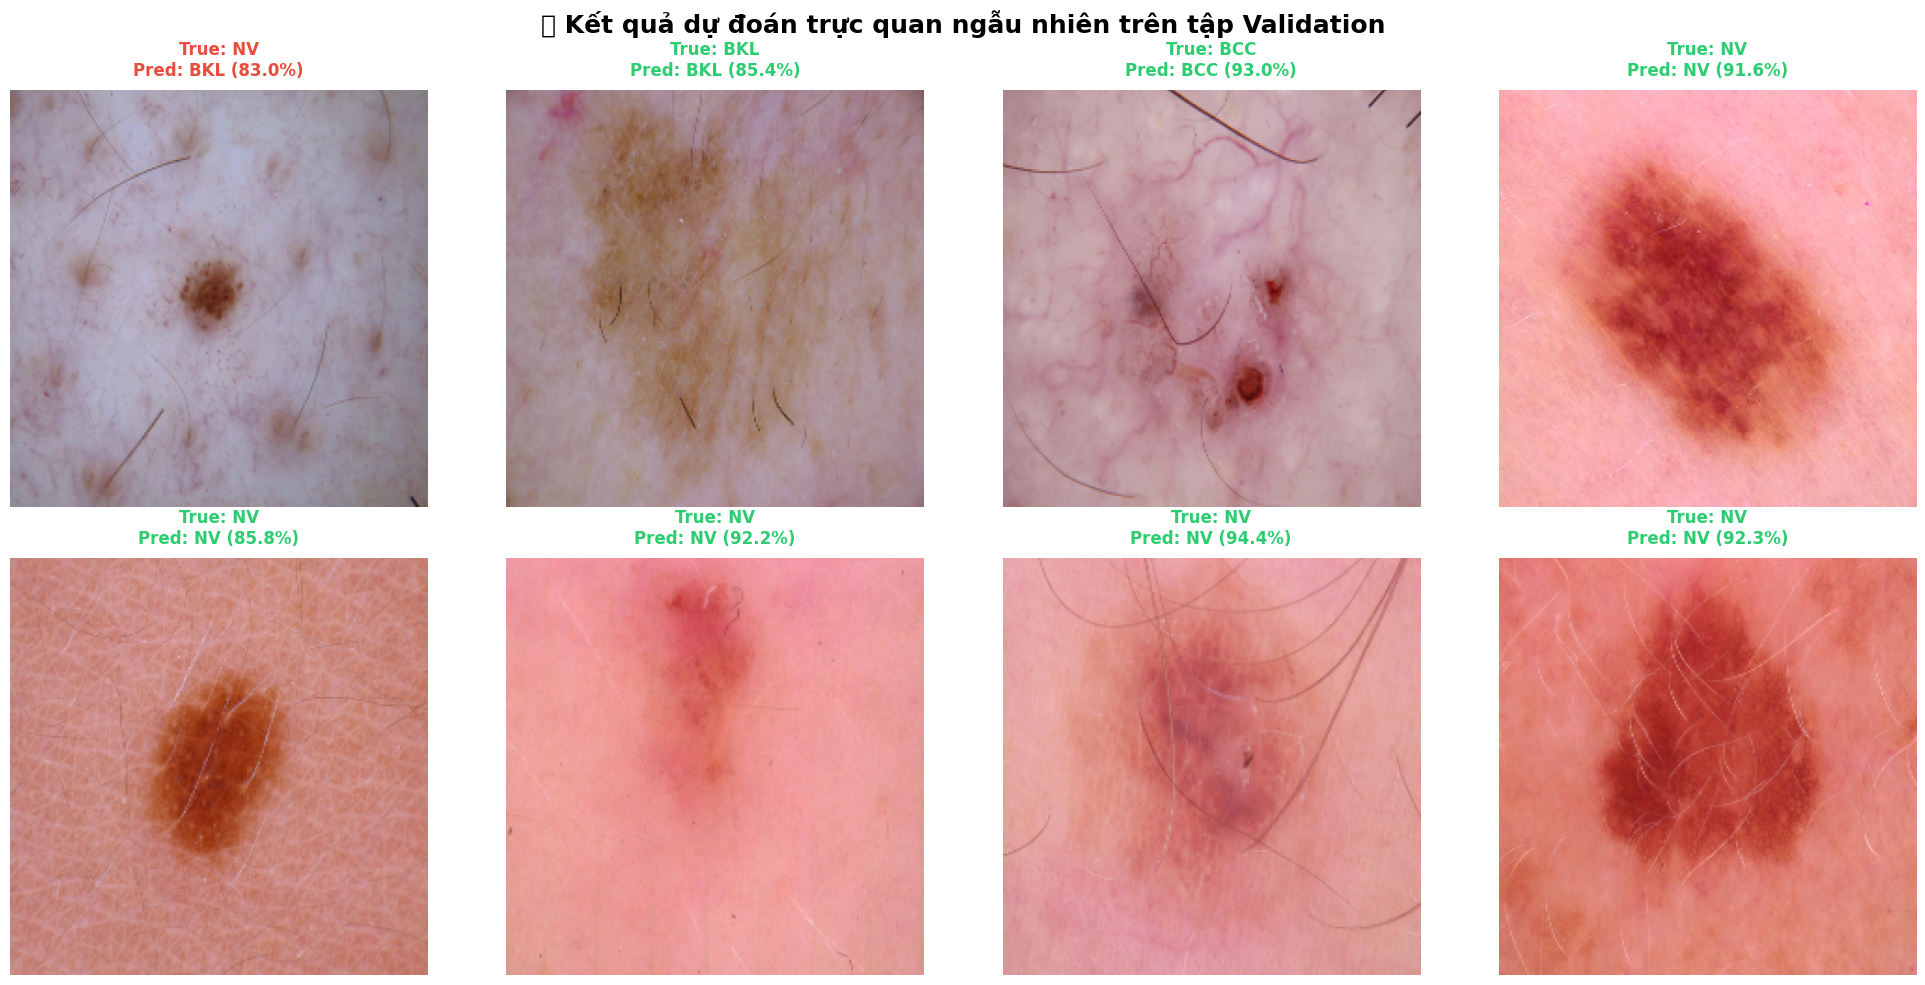

In [9]:
# 9. Trực quan hóa các mẫu từ Validation để Model dự đoán thử
model.eval()
dx_names = {
    0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'
}

dataset_size = len(val_dataset)
random_indices = random.sample(range(dataset_size), 8)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        img_tensor, tab_tensor, label = val_dataset[idx]
        img_input = img_tensor.unsqueeze(0).to(device)
        tab_input = tab_tensor.unsqueeze(0).to(device)
        
        outputs = model(img_input, tab_input)
        probabilities = torch.softmax(outputs, dim=1)[0]
        pred_label = torch.argmax(probabilities).item()
        confidence = probabilities[pred_label].item() * 100
        
        # De-normalize
        img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        axes[i].imshow(img_np)
        axes[i].axis('off')
        
        true_class = dx_names[label.item()]
        pred_class = dx_names[pred_label]
        is_correct = (label.item() == pred_label)
        color = '#2ecc71' if is_correct else '#e74c3c'
        
        title_text = f"True: {true_class.upper()}\nPred: {pred_class.upper()} ({confidence:.1f}%)"
        axes[i].set_title(title_text, fontsize=12, color=color, weight='bold', pad=10)

plt.suptitle('🔍 Kết quả dự đoán trực quan ngẫu nhiên trên tập Validation', fontsize=18, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

/var/folders/q5/7lqn73z14kdgf2zsrn7wn0540000gn/T/ipykernel_40086/4029604935.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


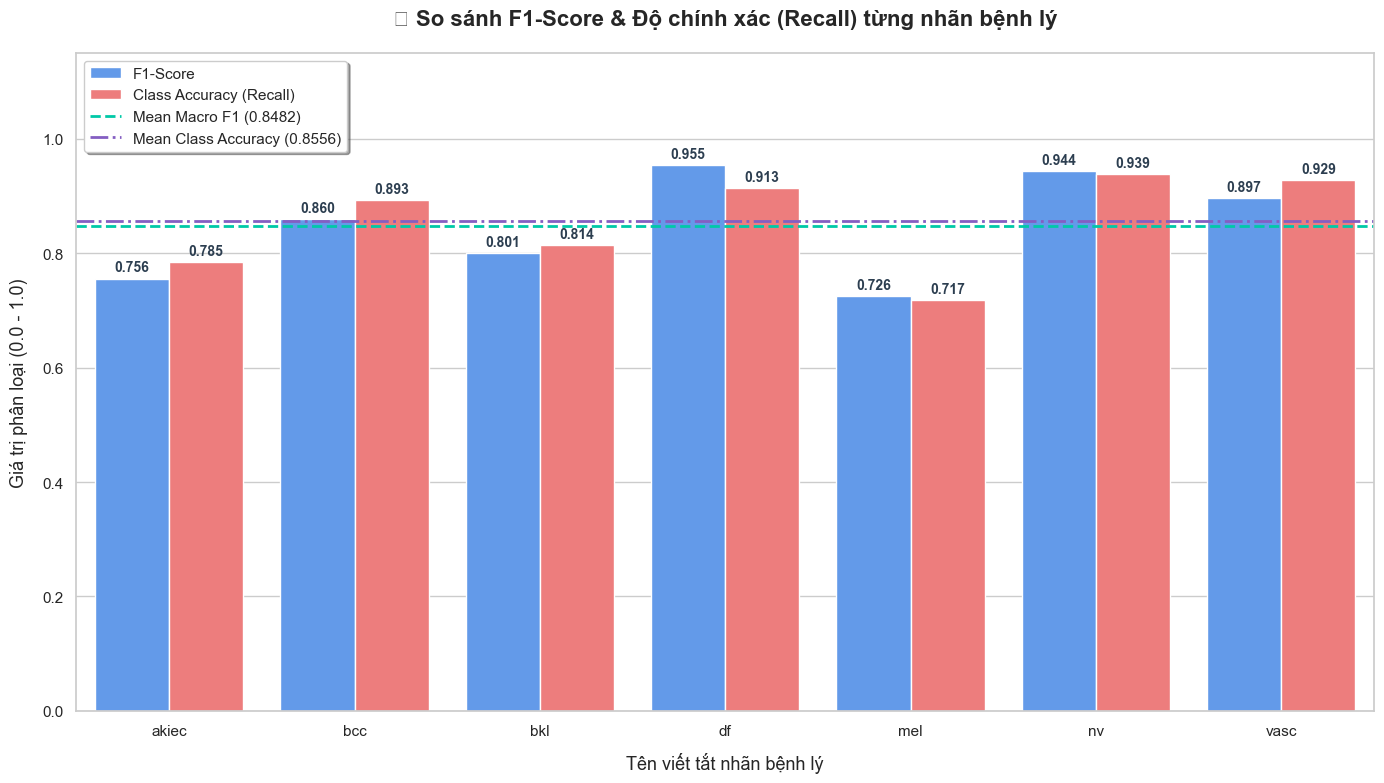

In [10]:
# 10. Vẽ biểu đồ F1-Score & Accuracy từng nhãn bệnh lý
from sklearn.metrics import f1_score, recall_score

classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
f1_per_class = f1_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
mean_f1 = np.mean(f1_per_class)
mean_acc = np.mean(recall_per_class)

df_metrics = pd.DataFrame({
    'Lớp': classes * 2,
    'Giá trị': np.concatenate([f1_per_class, recall_per_class]),
    'Chỉ số': ['F1-Score'] * len(classes) + ['Class Accuracy (Recall)'] * len(classes)
})

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
palette_colors = {'F1-Score': '#4D96FF', 'Class Accuracy (Recall)': '#FF6B6B'}
ax = sns.barplot(data=df_metrics, x='Lớp', y='Giá trị', hue='Chỉ số', palette=palette_colors)

plt.axhline(y=mean_f1, color='#00C9A7', linestyle='--', linewidth=2, label=f'Mean Macro F1 ({mean_f1:.4f})')
plt.axhline(y=mean_acc, color='#845EC2', linestyle='-.', linewidth=2, label=f'Mean Class Accuracy ({mean_acc:.4f})')

plt.title('📊 So sánh F1-Score & Độ chính xác (Recall) từng nhãn bệnh lý', fontsize=16, weight='bold', pad=20)
plt.xlabel('Tên viết tắt nhãn bệnh lý', fontsize=13, labelpad=10)
plt.ylabel('Giá trị phân loại (0.0 - 1.0)', fontsize=13, labelpad=10)
plt.ylim(0, 1.15)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, weight='bold', color='#2c3e50')

plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()